In [2]:
import cv2
import torch
import numpy as np

In [3]:
from petroscope.segmentation.models.hrnet.model import HRNet

2026-03-10T05:04:40.549052+0000 INFO Loading module: torch
2026-03-10T05:04:40.554285+0000 INFO Loading module: torch.nn


In [ ]:
device = "cuda:1"
n_classes = 10
model_path = "/home/n.yakovlev/petroscope/petroscope/S1v2_S2v2_x05.pth"
model_chpnt = torch.load(model_path)

2026-03-10T05:04:44.120125+0000 INFO 🔄 Downloading ImageNet pretrained weights for HRNETV2_W18...


Downloading: "https://opr0mq.dm.files.1drv.com/y4mIoWpP2n-LUohHHANpC0jrOixm1FZgO2OsUtP2DwIozH5RsoYVyv_De5wDgR6XuQmirMV3C0AljLeB-zQXevfLlnQpcNeJlT9Q8LwNYDwh3TsECkMTWXCUn3vDGJWpCxQcQWKONr5VQWO1hLEKPeJbbSZ6tgbWwJHgHF7592HY7ilmGe39o5BhHz7P9QqMYLBts6V7QGoaKrr0PL3wvvR4w" to /home/n.yakovlev/.cache/torch/hub/checkpoints/hrnetv2_imagenet_83f6e6e9c946b70a.pth


2026-03-10T05:04:44.887317+0000 WARNING Failed to load pretrained weights for hrnetv2_w18: HTTP Error 404: Not Found
2026-03-10T05:04:44.888700+0000 INFO ⚠️  Continuing with random initialization


<All keys matched successfully>

In [27]:
model_chpnt["model_state"]["model.backbone.conv1.weight"] += torch.randn_like(model_chpnt["model_state"]["model.backbone.conv1.weight"]) * 0.05

In [28]:
model = HRNet._create_from_checkpoint(model_chpnt, device)
model.model.load_state_dict(model_chpnt["model_state"])

2026-03-10T06:39:28.405771+0000 INFO 🔄 Downloading ImageNet pretrained weights for HRNETV2_W18...


Downloading: "https://opr0mq.dm.files.1drv.com/y4mIoWpP2n-LUohHHANpC0jrOixm1FZgO2OsUtP2DwIozH5RsoYVyv_De5wDgR6XuQmirMV3C0AljLeB-zQXevfLlnQpcNeJlT9Q8LwNYDwh3TsECkMTWXCUn3vDGJWpCxQcQWKONr5VQWO1hLEKPeJbbSZ6tgbWwJHgHF7592HY7ilmGe39o5BhHz7P9QqMYLBts6V7QGoaKrr0PL3wvvR4w" to /home/n.yakovlev/.cache/torch/hub/checkpoints/hrnetv2_imagenet_83f6e6e9c946b70a.pth


2026-03-10T06:39:29.539262+0000 WARNING Failed to load pretrained weights for hrnetv2_w18: HTTP Error 404: Not Found
2026-03-10T06:39:29.540763+0000 INFO ⚠️  Continuing with random initialization


<All keys matched successfully>

In [29]:
list(model_chpnt["model_state"].keys())[:20]

['model.backbone.conv1.weight',
 'model.backbone.bn1.weight',
 'model.backbone.bn1.bias',
 'model.backbone.bn1.running_mean',
 'model.backbone.bn1.running_var',
 'model.backbone.bn1.num_batches_tracked',
 'model.backbone.conv2.weight',
 'model.backbone.bn2.weight',
 'model.backbone.bn2.bias',
 'model.backbone.bn2.running_mean',
 'model.backbone.bn2.running_var',
 'model.backbone.bn2.num_batches_tracked',
 'model.backbone.layer1.0.conv1.weight',
 'model.backbone.layer1.0.bn1.weight',
 'model.backbone.layer1.0.bn1.bias',
 'model.backbone.layer1.0.bn1.running_mean',
 'model.backbone.layer1.0.bn1.running_var',
 'model.backbone.layer1.0.bn1.num_batches_tracked',
 'model.backbone.layer1.0.conv2.weight',
 'model.backbone.layer1.0.bn2.weight']

In [30]:
model_chpnt["model_state"]["model.backbone.conv1.weight"].mean()

tensor(0.0031, device='cuda:0')

In [31]:
model_chpnt["model_state"]["model.backbone.conv1.weight"].std()

tensor(0.1553, device='cuda:0')

In [32]:
import matplotlib.pyplot as plt

In [33]:
img_path = "/home/n.yakovlev/petroscope/petroscope/petroscope/images/01.jpg"


In [34]:
img = cv2.imread(img_path).astype(np.float32) /255

In [35]:
print(img.max())
print(img.shape)

0.93333334
(2547, 3396, 3)


In [36]:
import cv2
import numpy as np
import torch
from skimage.segmentation import slic, felzenszwalb


def compute_superpixels(
    img_bgr: np.ndarray,
    method: str = "slic",
    slic_kwargs=None,
    felz_kwargs=None,
) -> np.ndarray:
    """
    img_bgr: np.ndarray, H x W x 3, BGR в [0, 255] или [0, 1].
    method: 'slic' или 'felzenszwalb'
    return: labels, shape (H, W), тип int
    """
    if img_bgr.dtype != np.float32 and img_bgr.dtype != np.float64:
        img = img_bgr.astype(np.float32) / 255.0
    else:
        img = img_bgr.copy()

    # skimage ожидает RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if method == "slic":
        if slic_kwargs is None:
            slic_kwargs = dict(n_segments=800, compactness=20.0, start_label=0)
        labels = slic(img_rgb, **slic_kwargs)
    elif method == "felzenszwalb":
        if felz_kwargs is None:
            # scale / sigma / min_size можно подобрать под свои картинки
            felz_kwargs = dict(scale=200, sigma=1.0, min_size=10)
        labels = felzenszwalb(img_rgb, **felz_kwargs)
    else:
        raise ValueError(f"Unknown superpixel method: {method}")

    return labels.astype(np.int32)


def superpixel_postprocess(
    logits: torch.Tensor,
    superpixels: np.ndarray,
    vote_mode: str = "majority_argmax",
    from_logits: bool = True,
    device: torch.device | str | None = None,
) -> torch.Tensor:
    """
    logits: torch.Tensor, shape (1, C, H, W) или (C, H, W)
    superpixels: np.ndarray, shape (H, W), int
    vote_mode:
        'majority_argmax' - голосование по argmax внутри суперпикселя
        'mean_proba'      - усреднение вероятностей по суперпикселю
    from_logits: если True, применяем softmax к logits
    device: на какой девайс вернуть результат (по умолчанию logits.device)

    return: torch.Tensor, shape (H, W), dtype=torch.long (классы)
    """
    if logits.dim() == 4:
        # (1, C, H, W)
        logits = logits[0]

    C, H, W = logits.shape
    assert superpixels.shape == (H, W), "Размеры superpixels и logits не совпадают"

    if from_logits:
        with torch.no_grad():
            probs = torch.softmax(logits, dim=0)  # (C, H, W)
    else:
        probs = logits

    # на CPU и в numpy
    probs_np = probs.detach().cpu().numpy()     # (C, H, W)
    labels_sp = superpixels.astype(np.int32)    # (H, W)

    out_labels = np.zeros((H, W), dtype=np.int32)
    unique_sp = np.unique(labels_sp)

    if vote_mode == "majority_argmax":
        # 1) сначала пиксельные argmax'ы
        pixel_labels = probs_np.argmax(axis=0)  # (H, W)
        for sp_id in unique_sp:
            mask = (labels_sp == sp_id)
            # голоса внутри суперпикселя
            sp_classes = pixel_labels[mask]
            # какая метка встречается чаще всего
            classes, counts = np.unique(sp_classes, return_counts=True)
            majority_class = int(classes[counts.argmax()])
            out_labels[mask] = majority_class

    elif vote_mode == "mean_proba":
        # 2) усредняем вектор вероятностей по суперпикселю и берём argmax
        for sp_id in unique_sp:
            mask = (labels_sp == sp_id)  # (H, W)
            # вытаскиваем (C, N_pixels)
            sp_probs = probs_np[:, mask]
            # средняя вероятность по суперпикселю
            mean_probs = sp_probs.mean(axis=1)  # (C,)
            cls = int(mean_probs.argmax())
            out_labels[mask] = cls
    else:
        raise ValueError(f"Unknown vote_mode: {vote_mode}")

    if device is None:
        device = logits.device
    return torch.from_numpy(out_labels).to(device=device, dtype=torch.long)


In [37]:
model.model.eval()
img = cv2.imread(img_path).astype(np.float32) /255
img = torch.from_numpy(img).to(device).permute(2,0,1).unsqueeze(0)
with torch.inference_mode():
    pred = model.model(img)

In [38]:
model.model.eval()
img_bgr = cv2.imread(img_path)   # H x W x 3, uint8
img = img_bgr.astype(np.float32) / 255.0

# инференс
x = torch.from_numpy(img).to(device).permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
with torch.inference_mode():
    logits = model.model(x)  # (1, C, H, W) — логиты

# считаем суперпиксели (выбери метод и параметры)
sp_labels = compute_superpixels(
    img_bgr,
    method="felzenszwalb",
    # slic_kwargs=dict(n_segments=1000, compactness=15.0, start_label=0),
)

pred_sp_majority = superpixel_postprocess(
    logits, sp_labels, vote_mode="majority_argmax", from_logits=True
)

pred_sp_mean = superpixel_postprocess(
    logits, sp_labels, vote_mode="mean_proba", from_logits=True
)

pred_vis = pred_sp_mean.detach().cpu().numpy().astype(np.uint8)

In [39]:
logits.size()

torch.Size([1, 10, 2547, 3396])

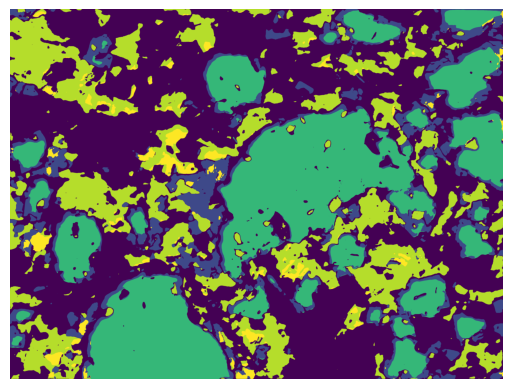

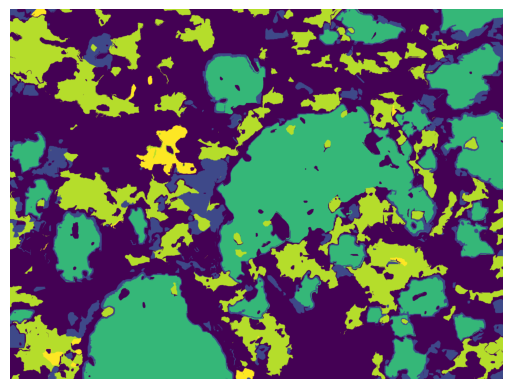

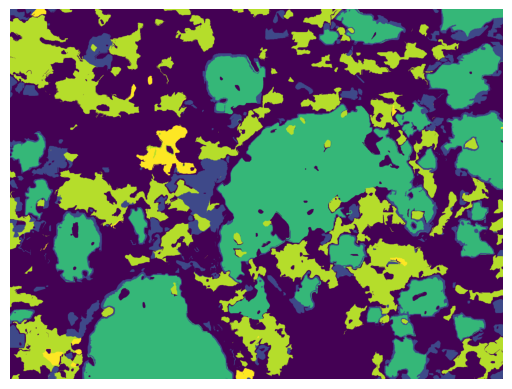

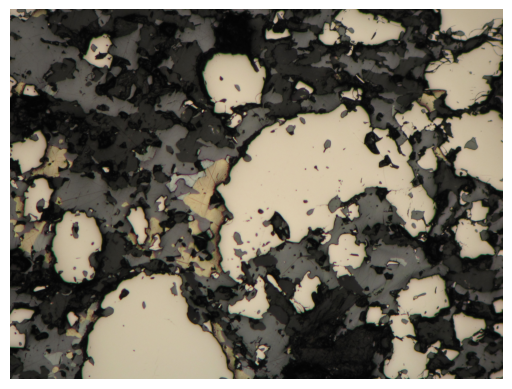

In [40]:
plt.imshow(logits[0].argmax(dim=0).cpu())
plt.axis("off")
plt.show()
plt.imshow(pred_sp_mean.cpu())
plt.axis("off")
plt.show()
plt.imshow(pred_sp_majority.cpu())
plt.axis("off")
plt.show()
plt.imshow(img[..., [2,1,0]])
plt.axis("off")
plt.show()

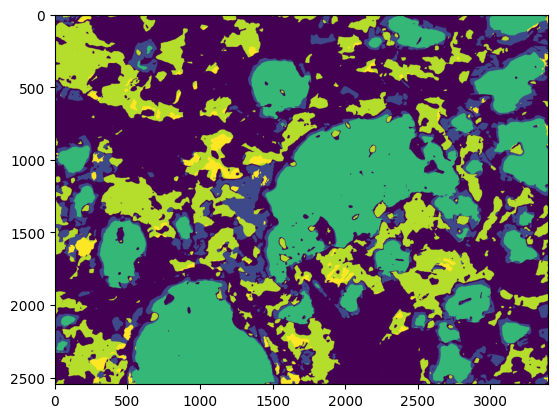

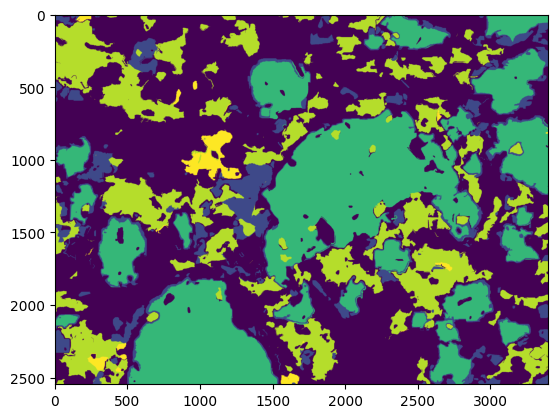

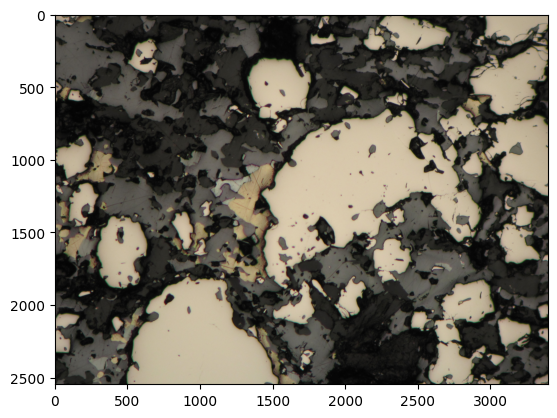

In [41]:
plt.imshow(logits[0].argmax(dim=0).cpu())
plt.show()
plt.imshow(pred_sp_mean.cpu())
plt.show()
plt.imshow(img[..., [2,1,0]])
plt.show()

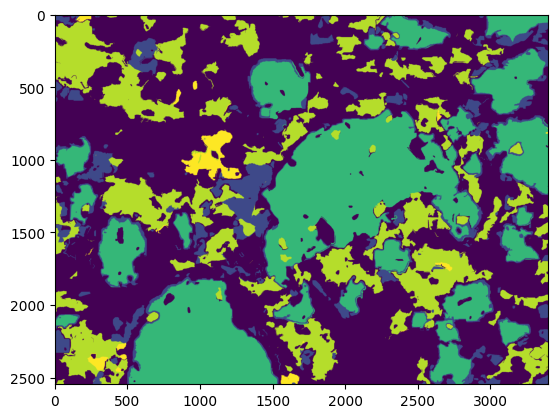

In [42]:
plt.imshow(pred_sp_mean.cpu())
plt.show()

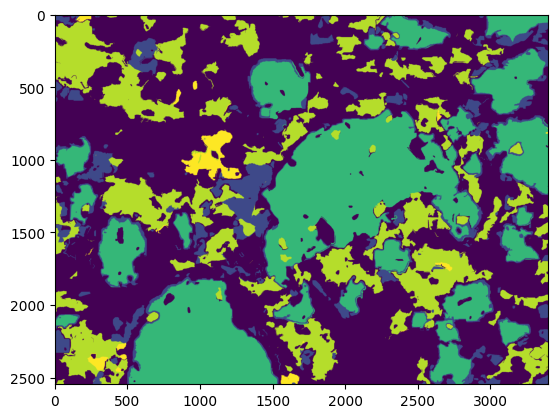

In [43]:
plt.imshow(pred_sp_mean.cpu())
plt.show()

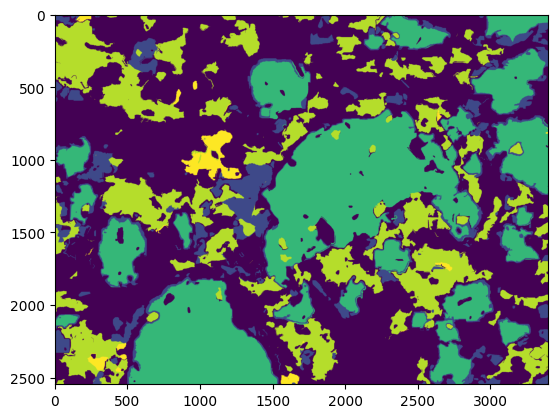

In [44]:
plt.imshow(pred_sp_mean.cpu())
plt.show()

In [45]:
plt.imshow(img.permute(0, 2, 3, 1)[0].cpu()[...,[2, 1, 0]])
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'permute'

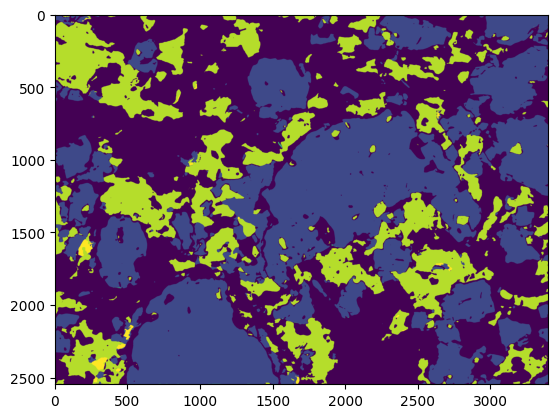

In [ ]:
plt.imshow(pred[0].argmax(dim=0).cpu())
plt.show()